# Home Credit: Model tuning

**Completed: eight candidates × five temporal folds; five control folds reused.**

Does bounded tuning improve stability without removing validated feature blocks? All 700 features were retained. This is an executed review of aggregate results, not a retraining notebook. The untouched final holdout is weeks 73–91.

In [1]:
import hashlib
import json
from pathlib import Path

import pandas as pd
from IPython.display import SVG, display

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/model_tuning.json").is_file()
)
evidence = root / "reports/model_tuning/metrics.json"
assert (
    hashlib.sha256(evidence.read_bytes()).hexdigest()
    == "5b2dbc4b5dfcbdcfc19e5d609cf6742065b4642f969ef53df83b2d726acb8295"
)
result = json.loads(evidence.read_text())
assert result["complete"] and not result["smoke"]
assert result["outer_holdout_touched"] is False
assert result["completed_new_model_folds"] == 40
print(result["scope"])
table = pd.DataFrame(result["rows"]).sort_values(
    "mean_fold_stability", ascending=False, kind="stable"
)
display(table.round(6).reset_index(drop=True))

Development-only aggregate excerpt from the completed S3 study; not a holdout or leaderboard result.


,candidate,mean_fold_stability,oof_auc,oof_average_precision,oof_brier,oof_log_loss,worst_fold_stability
0,trial_006,0.601238,0.849286,0.207351,0.032347,0.126222,0.479200
1,trial_007,0.592773,0.848767,0.205642,0.032392,0.126436,0.412354
2,trial_004,0.591862,0.849275,0.207925,0.032335,0.126189,0.453410
3,trial_003,0.590118,0.848861,0.207299,0.032357,0.126324,0.424922
4,control,0.585188,0.846894,0.204525,0.032425,0.126805,0.393682
5,trial_008,0.584799,0.847315,0.205330,0.032400,0.126676,0.411907
6,trial_002,0.581734,0.846732,0.204147,0.032426,0.126830,0.423080
7,trial_001,0.573195,0.847154,0.205705,0.032413,0.126785,0.407772
8,trial_005,0.546016,0.845168,0.202103,0.032517,0.127256,0.252920


## Improvement and its limits

The primary objective is the mean of five official stability scores: mean weekly Gini + 88 × min(temporal slope, 0) − 0.5 × residual standard deviation. Pooled OOF ROC AUC and average precision support ranking evaluation; Brier and log loss support probability evaluation.

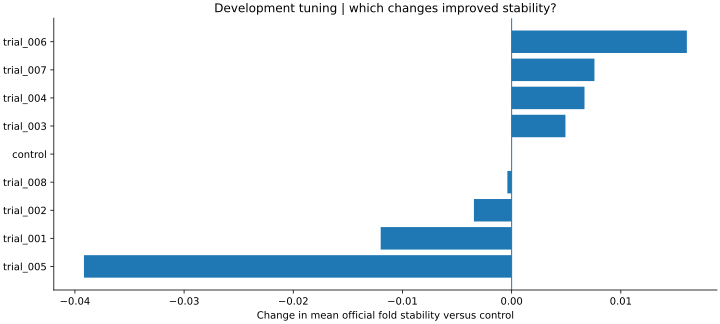

In [2]:
import matplotlib

matplotlib.use("Agg")
from io import StringIO

import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["svg.hashsalt"] = "home-credit-tuning-review"
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ranked = table.iloc[::-1]
control = float(table.loc[table["candidate"] == "control", "mean_fold_stability"].iloc[0])
ax.barh(ranked["candidate"], ranked["mean_fold_stability"] - control)
ax.axvline(0, linewidth=1)
ax.set(
    xlabel="Change in mean official fold stability versus control",
    title="Development tuning | which changes improved stability?",
)
ax.spines[["top", "right"]].set_visible(False)
buffer = StringIO()
fig.savefig(buffer, format="svg", metadata={"Date": None})
display(SVG(data=buffer.getvalue()))
plt.close(fig)

,control,delta,fold,trial_006
0,0.393682,0.085518,1,0.479200
1,0.667723,0.002607,2,0.670330
2,0.497823,-0.010469,3,0.487354
3,0.682806,-0.002493,4,0.680313
4,0.683906,0.005085,5,0.688992


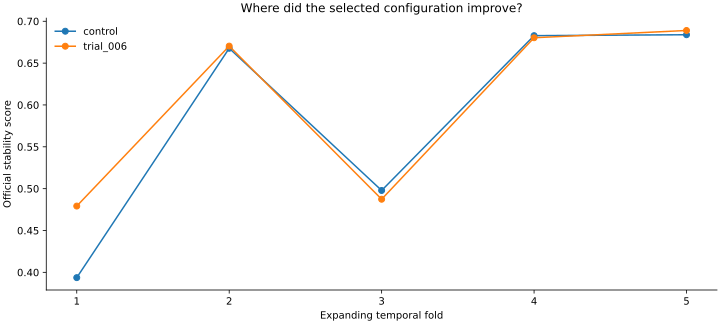

The leader improves three of five folds; most stability gain comes from fold 1. Trial 004 has slightly better probability metrics. Repeated selection on these folds is not unbiased validation.


In [3]:
folds = pd.DataFrame(result["folds"])
display(folds.round(6))
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
for name in ["control", "trial_006"]:
    ax.plot(folds["fold"], folds[name], "o-", label=name)
ax.set(
    xlabel="Expanding temporal fold",
    ylabel="Official stability score",
    title="Where did the selected configuration improve?",
)
ax.set_xticks(folds["fold"])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
buffer = StringIO()
fig.savefig(buffer, format="svg", metadata={"Date": None})
display(SVG(data=buffer.getvalue()))
plt.close(fig)
assert int((folds["delta"] > 0).sum()) == 3
print(result["interpretation"])

## Decision

Retain `trial_006` as the tuned LightGBM development incumbent. Mean fold stability rises from **0.585188 to 0.601238**, but folds 3 and 4 regress slightly. Trial 004 has marginally better Brier and log loss; the official stability objective, not probability error, selects trial 006.

Next, compare a small, fixed set of blends using saved LightGBM, XGBoost and CatBoost predictions. Do not repeat the completed 40 fits. The next launcher is `bash scripts/start_model_selection.sh --bucket YOUR_ARTIFACT_BUCKET`. Successful completion publishes the canonical `notebooks/08_model_selection.ipynb` and a durable S3-backed run report.

After development choices are frozen: evaluate the holdout once, refit and validate the complete inference pipeline, then let the owner generate, validate and download a submission from notebook code. **No Kaggle upload is automated.** A new leaderboard score is not implied by these development results.

In [4]:
print("Selected parameters:")
print(json.dumps(result["selected_parameters"], indent=2, sort_keys=True))
print("Training commit:", result["training_git_commit"])
print("Full source study SHA-256:", result["source_study_sha256"])
print("Study completed UTC:", result["completed_utc"])
print("The committed JSON is an aggregate excerpt, not the full S3 ledger.")

Selected parameters:
{
  "bagging_fraction": 0.8128296528743939,
  "feature_fraction": 0.7588755879033762,
  "lambda_l1": 9.093011170854757,
  "lambda_l2": 36.49985170247936,
  "min_data_in_leaf": 100,
  "num_leaves": 31
}
Training commit: 2e52dd908f2b30a783e37157ae9801e0679cc666
Full source study SHA-256: 0de34e51d0a97bd8cd4064931f81135ba3a5299c30e76b3ca1f178f0cb3569dd
Study completed UTC: 2026-09-07T07:40:22Z
The committed JSON is an aggregate excerpt, not the full S3 ledger.
